# Analyse exploratoire — BRFSS Heart Analytics

**Jeu de données** : *Behavioral Risk Factor Surveillance System* (BRFSS 2015, CDC)
— 253 680 répondants, 22 variables initiales.

**Objectif** : comprendre la structure des données, évaluer leur qualité et
identifier les facteurs associés à la maladie cardiovasculaire, avant toute
modélisation.

> ⚠️ **Limite méthodologique** — les variables explicatives sont auto-déclarées
> **au même moment** que la variable cible. Ce qui suit décrit donc des
> **associations transversales**, et non des relations de cause à effet ni des
> prédictions d'événements futurs.

---

In [1]:
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

RACINE = Path.cwd().parent.parent
FIGURES = RACINE / "06_rapport" / "figures" / "eda"
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["font.size"] = 10

# Palette du projet : bleu = sains, rouge = malades. Conservée dans tout le
# notebook pour que les figures se lisent sans relire la légende.
BLEU, ROUGE = "#2E5C8A", "#C1443F"


def enregistrer(nom):
    """Sauvegarde la figure courante pour réutilisation dans le rapport."""
    plt.savefig(FIGURES / f"{nom}.png")


print("Environnement pret.")

Environnement pret.


## 1. Chargement des données

Les données proviennent de la table analytique produite par le pipeline ETL
(`python run_etl.py`), et non du CSV brut : l'analyse porte ainsi exactement sur
ce qui alimente l'entrepôt et les modèles.

In [2]:
BASE = RACINE / "02_data_warehouse" / "heart.duckdb"

with duckdb.connect(str(BASE), read_only=True) as conn:
    df = conn.execute("SELECT * FROM analytical_base").df()

print(f"{len(df):,} lignes x {df.shape[1]} colonnes")
df.head()

253,680 lignes x 31 colonnes


,respondent_id,heart_disease,high_bp,high_chol,chol_check,bmi,smoker,stroke,diabetes,phys_activity,fruits,veggies,hvy_alcohol,any_healthcare,no_doc_cost,gen_hlth,ment_hlth_days,phys_hlth_days,diff_walk,sex,age_group,education,income,bmi_class,total_unhealthy_days,risk_factor_count,healthy_habits_count,has_care_access,flag_bmi_extreme,flag_profil_duplique,flag_sante_incoherente
0,1,0,1,1,1,40.0,1,0,0,0,0,1,0,1,0,5,18,15,1,0,9,4,3,6,30,5,1,1,0,0,0
1,2,0,0,0,0,25.0,1,0,0,1,0,0,0,0,1,3,0,0,0,0,7,6,1,3,0,1,1,0,0,0,0
2,3,0,1,1,1,28.0,0,0,0,0,1,0,0,1,1,5,30,30,1,0,9,4,8,3,30,3,1,0,0,0,0
3,4,0,1,0,1,27.0,0,0,0,1,1,1,0,1,0,2,0,0,0,0,11,3,6,3,0,1,3,1,0,0,0
4,5,0,1,1,1,24.0,0,0,0,1,1,1,0,1,0,2,3,0,0,0,11,5,4,2,3,2,3,1,0,0,0


In [3]:
apercu = pd.DataFrame({
    "type": df.dtypes.astype(str),
    "valeurs_distinctes": df.nunique(),
    "manquantes": df.isna().sum(),
})
apercu

,type,valeurs_distinctes,manquantes
respondent_id,int64,253680,0
heart_disease,int8,2,0
high_bp,int8,2,0
high_chol,int8,2,0
chol_check,int8,2,0
bmi,float32,84,0
smoker,int8,2,0
stroke,int8,2,0
diabetes,int8,3,0
phys_activity,int8,2,0


**Premier constat** : aucune valeur manquante sur l'ensemble des colonnes. C'est
inhabituel et cela s'explique — le jeu Kaggle est une version déjà nettoyée du
BRFSS, dont les non-réponses ont été écartées en amont. Il n'y a donc pas de
stratégie d'imputation à concevoir, mais il faut garder en tête que **cette
sélection préalable a pu écarter des profils particuliers** (les personnes les
plus fragiles répondent moins).

## 2. Qualité des données : le cas des doublons exacts

Le jeu contient **23 899 lignes strictement identiques à une autre** (9,42 %).
Le réflexe habituel serait de les supprimer. Avant cela, il faut trancher une
question : s'agit-il d'**erreurs de saisie** (le même répondant compté plusieurs
fois) ou de **collisions légitimes** (deux répondants différents partageant le
même profil) ?

Les deux hypothèses font des prédictions opposées et vérifiables.

### Test 1 — le taux de doublons dépend-il de la taille de l'échantillon ?

- **Si erreurs de saisie** → le taux est une propriété du fichier : il reste
  **constant** quel que soit l'échantillon.
- **Si collisions** → le taux **croît avec la taille** : plus il y a de
  répondants, plus deux d'entre eux finissent par coïncider (paradoxe des
  anniversaires).

In [4]:
colonnes_source = [
    "heart_disease", "high_bp", "high_chol", "chol_check", "bmi", "smoker",
    "stroke", "diabetes", "phys_activity", "fruits", "veggies", "hvy_alcohol",
    "any_healthcare", "no_doc_cost", "gen_hlth", "ment_hlth_days",
    "phys_hlth_days", "diff_walk", "sex", "age_group", "education", "income",
]

rng = np.random.default_rng(42)
resultats = []
for fraction in [0.05, 0.10, 0.25, 0.50, 1.00]:
    n = int(len(df) * fraction)
    taux = [
        df.sample(n, random_state=int(graine))[colonnes_source].duplicated().mean() * 100
        for graine in rng.integers(0, 10_000, 3)
    ]
    resultats.append({"taille": n, "taux_doublons_pct": round(np.mean(taux), 2)})

test1 = pd.DataFrame(resultats)
test1

,taille,taux_doublons_pct
0,12684,1.50
1,25368,2.55
2,63420,4.47
3,126840,6.69
4,253680,9.42


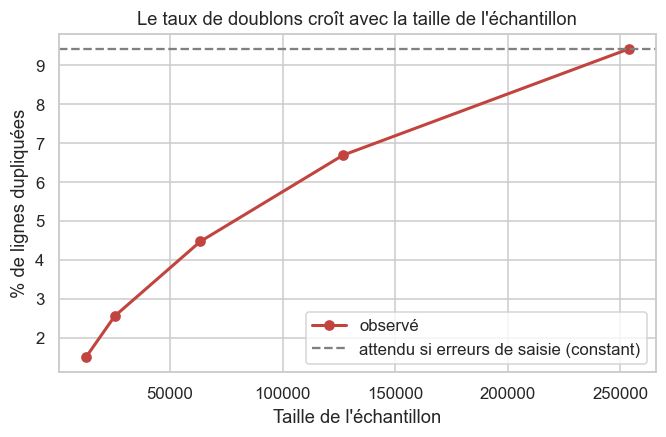

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(test1.taille, test1.taux_doublons_pct, "o-", color=ROUGE, lw=2, label="observé")
ax.axhline(9.42, ls="--", c="grey", label="attendu si erreurs de saisie (constant)")
ax.set_xlabel("Taille de l'échantillon")
ax.set_ylabel("% de lignes dupliquées")
ax.set_title("Le taux de doublons croît avec la taille de l'échantillon")
ax.legend()
enregistrer("01_doublons_scaling")
plt.show()

Le taux passe de **1,50 %** à 12 684 lignes à **9,42 %** à 253 680. Il n'est pas
constant : l'hypothèse « erreurs de saisie » est écartée.

### Test 2 — quels profils sont dupliqués ?

Une erreur de saisie n'a aucune raison de viser préférentiellement certains
profils. Une collision, si : elle frappe d'abord les profils **les plus fréquents**.

In [6]:
masque = df[colonnes_source].duplicated(keep=False)
dupliques, uniques = df[masque], df[~masque]

comparaison = pd.DataFrame({
    "lignes dupliquées (%)": [
        (dupliques.ment_hlth_days == 0).mean() * 100,
        (dupliques.phys_hlth_days == 0).mean() * 100,
        (dupliques.bmi <= 30).mean() * 100,
        dupliques.heart_disease.mean() * 100,
    ],
    "lignes uniques (%)": [
        (uniques.ment_hlth_days == 0).mean() * 100,
        (uniques.phys_hlth_days == 0).mean() * 100,
        (uniques.bmi <= 30).mean() * 100,
        uniques.heart_disease.mean() * 100,
    ],
}, index=[
    "aucun jour de mal-être mental",
    "aucun jour de mal-être physique",
    "IMC <= 30",
    "atteintes d'une maladie cardiaque",
]).round(1)

comparaison

,lignes dupliquées (%),lignes uniques (%)
aucun jour de mal-être mental,95.7,65.0
aucun jour de mal-être physique,96.2,57.8
IMC <= 30,91.1,67.9
atteintes d'une maladie cardiaque,0.9,10.8


Les lignes dupliquées sont massivement des **profils banals** : 95,7 % déclarent
zéro jour de mal-être mental, contre 65 % chez les lignes uniques. Ce sont les
répondants « en bonne santé, IMC modéré, rien à signaler » — le profil le plus
courant de la population. Exactement ce qu'on attend de collisions.

### Test 3 — taille des groupes de doublons

In [7]:
tailles = df.groupby(colonnes_source).size().value_counts().sort_index()
print("Profils vus n fois :")
for taille, nombre in tailles.head(8).items():
    print(f"  {taille:>3}x : {nombre:>7,} profils distincts")
print(f"\n  groupe le plus important : {tailles.index.max()} lignes identiques")

Profils vus n fois :
    1x : 218,594 profils distincts
    2x :   7,219 profils distincts
    3x :   1,882 profils distincts
    4x :     790 profils distincts
    5x :     372 profils distincts
    6x :     248 profils distincts
    7x :     159 profils distincts
    8x :     107 profils distincts

  groupe le plus important : 59 lignes identiques


Le plus gros groupe compte **59 lignes identiques**. Aucun mécanisme d'erreur de
saisie plausible ne produit 59 copies d'un même enregistrement. En revanche, que
59 répondants sur 253 680 partagent le profil le plus commun est parfaitement
attendu.

### Test 4 — quel serait l'impact d'une déduplication ?

In [8]:
avec = df.heart_disease.mean() * 100
sans = df.drop_duplicates(subset=colonnes_source).heart_disease.mean() * 100

print(f"Prévalence avec doublons : {avec:.3f} %")
print(f"Prévalence sans doublons : {sans:.3f} %")
print(f"Écart introduit          : {sans - avec:+.3f} point de pourcentage")

Prévalence avec doublons : 9.419 %
Prévalence sans doublons : 10.322 %
Écart introduit          : +0.903 point de pourcentage


### Conclusion

Les quatre tests convergent : ce sont des **collisions légitimes entre répondants
distincts**. Les supprimer reviendrait à **effacer de vrais répondants en bonne
santé**, faisant grimper artificiellement la prévalence de 9,42 % à 10,32 %.

**Décision : les doublons sont conservés.** La déduplication n'aurait pas nettoyé
les données, elle les aurait biaisées.

> **Point connexe, à traiter en modélisation** : des profils identiques portent
> parfois des cibles opposées (deux personnes au même profil, l'une malade,
> l'autre non). Ce n'est pas un défaut de qualité mais de l'**erreur
> irréductible** — elle fixe un plafond de performance qu'aucun modèle ne pourra
> dépasser. Quantifiée dans le module 04.

## 3. La variable cible : un déséquilibre marqué

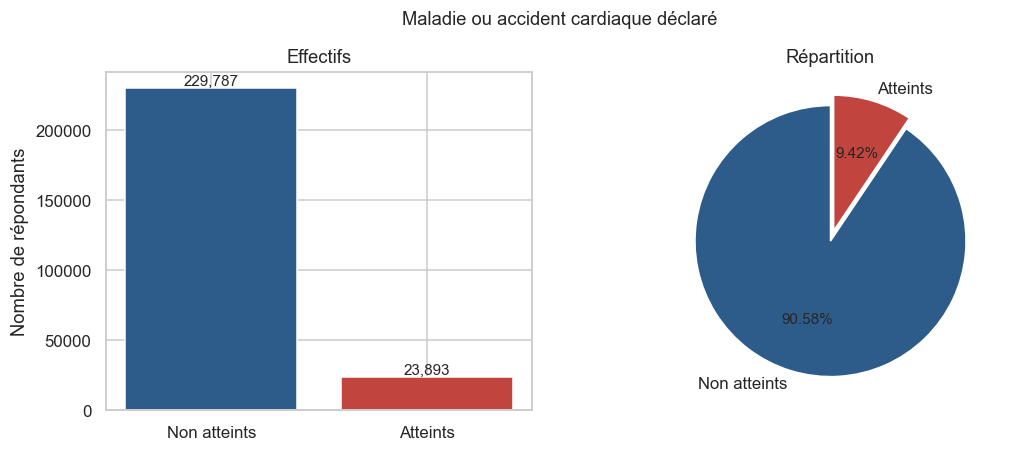

Prévalence : 9.42 %  —  ratio 1 malade pour 9.6 sains


In [9]:
effectifs = df.heart_disease.value_counts().sort_index()
parts = df.heart_disease.value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(["Non atteints", "Atteints"], effectifs, color=[BLEU, ROUGE])
axes[0].set_title("Effectifs")
axes[0].set_ylabel("Nombre de répondants")
for i, v in enumerate(effectifs):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].pie(parts, labels=["Non atteints", "Atteints"], colors=[BLEU, ROUGE],
            autopct="%1.2f%%", startangle=90, explode=(0, 0.08))
axes[1].set_title("Répartition")

plt.suptitle("Maladie ou accident cardiaque déclaré", y=1.02, fontsize=12)
enregistrer("02_cible_desequilibre")
plt.show()

print(f"Prévalence : {parts[1]:.2f} %  —  ratio 1 malade pour {effectifs[0]/effectifs[1]:.1f} sains")

**Conséquence directe pour la modélisation** : avec 9,42 % de positifs, un modèle
qui prédirait « aucun malade » pour tout le monde atteindrait **90,58 %
d'exactitude** tout en étant parfaitement inutile. L'*accuracy* est donc à
proscrire comme critère. On s'appuiera sur le **ROC-AUC**, le **PR-AUC**, le
**rappel** et le **F1**.

## 4. Distribution des variables continues

In [10]:
continues = ["bmi", "ment_hlth_days", "phys_hlth_days", "total_unhealthy_days"]

stats = df[continues].describe().T
stats["asymétrie"] = df[continues].skew()
stats["aplatissement"] = df[continues].kurtosis()
stats.round(2)

,count,mean,std,min,25%,50%,75%,max,asymétrie,aplatissement
bmi,253680.0,28.38,6.61,12.0,24.0,27.0,31.0,98.0,2.12,11.00
ment_hlth_days,253680.0,3.18,7.41,0.0,0.0,0.0,2.0,30.0,2.72,6.44
phys_hlth_days,253680.0,4.24,8.72,0.0,0.0,0.0,3.0,30.0,2.21,3.50
total_unhealthy_days,253680.0,6.38,10.22,0.0,0.0,1.0,7.0,30.0,1.54,0.82


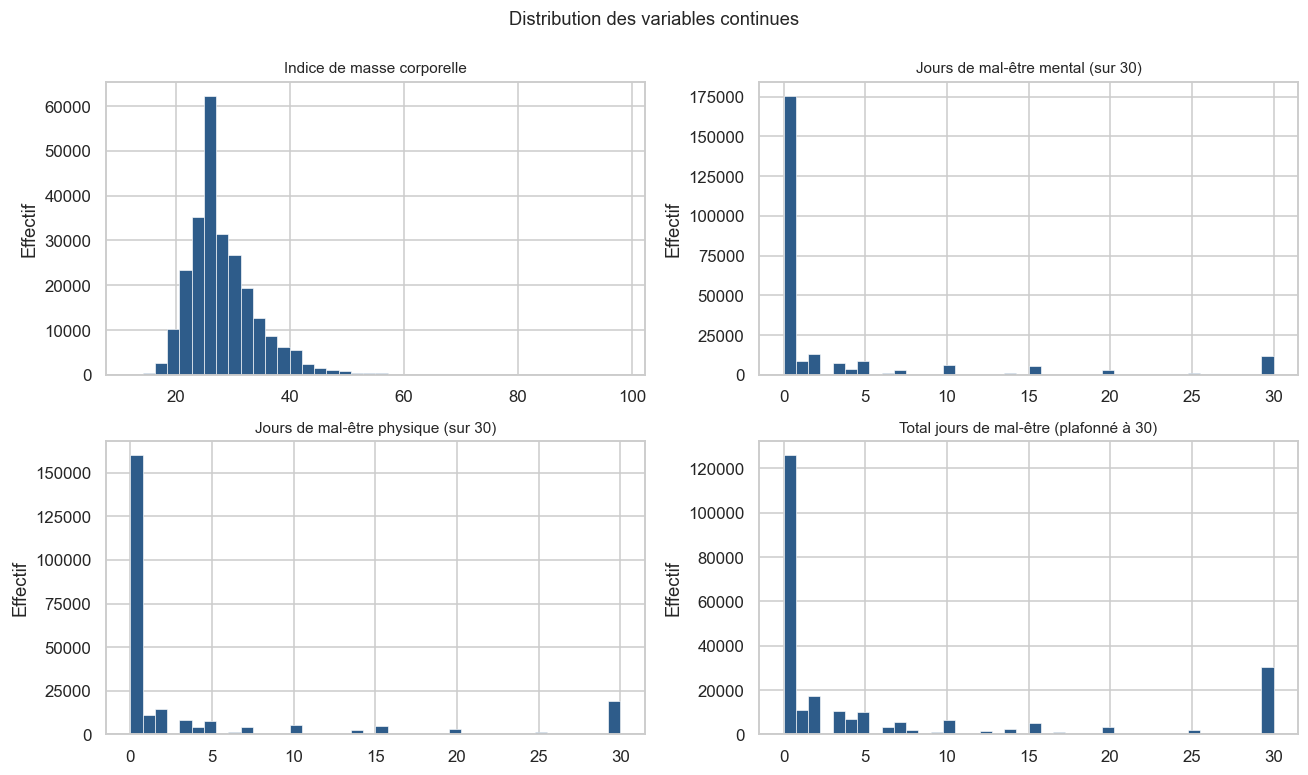

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
titres = {
    "bmi": "Indice de masse corporelle",
    "ment_hlth_days": "Jours de mal-être mental (sur 30)",
    "phys_hlth_days": "Jours de mal-être physique (sur 30)",
    "total_unhealthy_days": "Total jours de mal-être (plafonné à 30)",
}

for ax, colonne in zip(axes.ravel(), continues):
    ax.hist(df[colonne], bins=40, color=BLEU, edgecolor="white", linewidth=0.4)
    ax.set_title(titres[colonne], fontsize=10)
    ax.set_ylabel("Effectif")

plt.suptitle("Distribution des variables continues", y=1.00, fontsize=12)
plt.tight_layout()
enregistrer("03_distributions_continues")
plt.show()

Les variables de mal-être sont **extrêmement asymétriques** : l'écrasante majorité
des répondants déclare zéro jour, avec un pic secondaire à 30 jours (les
personnes en souffrance permanente). Ce sont donc des variables presque
binaires en pratique, avec une longue queue — un modèle linéaire aura du mal à
en tirer parti tel quel.

L'IMC est plus régulier mais reste asymétrique à droite, avec des valeurs
extrêmes jusqu'à 98 — physiologiquement très improbables, signalées par
`flag_bmi_extreme` sans être supprimées.

## 5. Prévalence par segment

C'est le cœur de l'analyse : quels profils sont les plus touchés ?

In [12]:
LIBELLES = {
    "age_group": {
        1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39", 5: "40-44", 6: "45-49",
        7: "50-54", 8: "55-59", 9: "60-64", 10: "65-69", 11: "70-74",
        12: "75-79", 13: "80+",
    },
    "gen_hlth": {1: "Excellente", 2: "Très bonne", 3: "Bonne", 4: "Moyenne", 5: "Mauvaise"},
    "bmi_class": {
        1: "Insuff. pond.", 2: "Normale", 3: "Surpoids",
        4: "Obésité I", 5: "Obésité II", 6: "Obésité III",
    },
    "income": {
        1: "<10k", 2: "10-15k", 3: "15-20k", 4: "20-25k",
        5: "25-35k", 6: "35-50k", 7: "50-75k", 8: "75k+",
    },
    "education": {
        1: "Aucune", 2: "Primaire", 3: "Sec. non ach.",
        4: "Secondaire", 5: "Sup. non ach.", 6: "Diplômé sup.",
    },
    "diabetes": {0: "Non", 1: "Prédiabète", 2: "Diabète"},
    "sex": {0: "Femme", 1: "Homme"},
}


def prevalence_par(colonne):
    """Prévalence de la maladie par modalité, avec effectifs."""
    resultat = df.groupby(colonne).agg(
        effectif=("heart_disease", "size"),
        prevalence=("heart_disease", "mean"),
    )
    resultat["prevalence"] *= 100
    resultat.index = resultat.index.map(LIBELLES.get(colonne, {}))
    return resultat

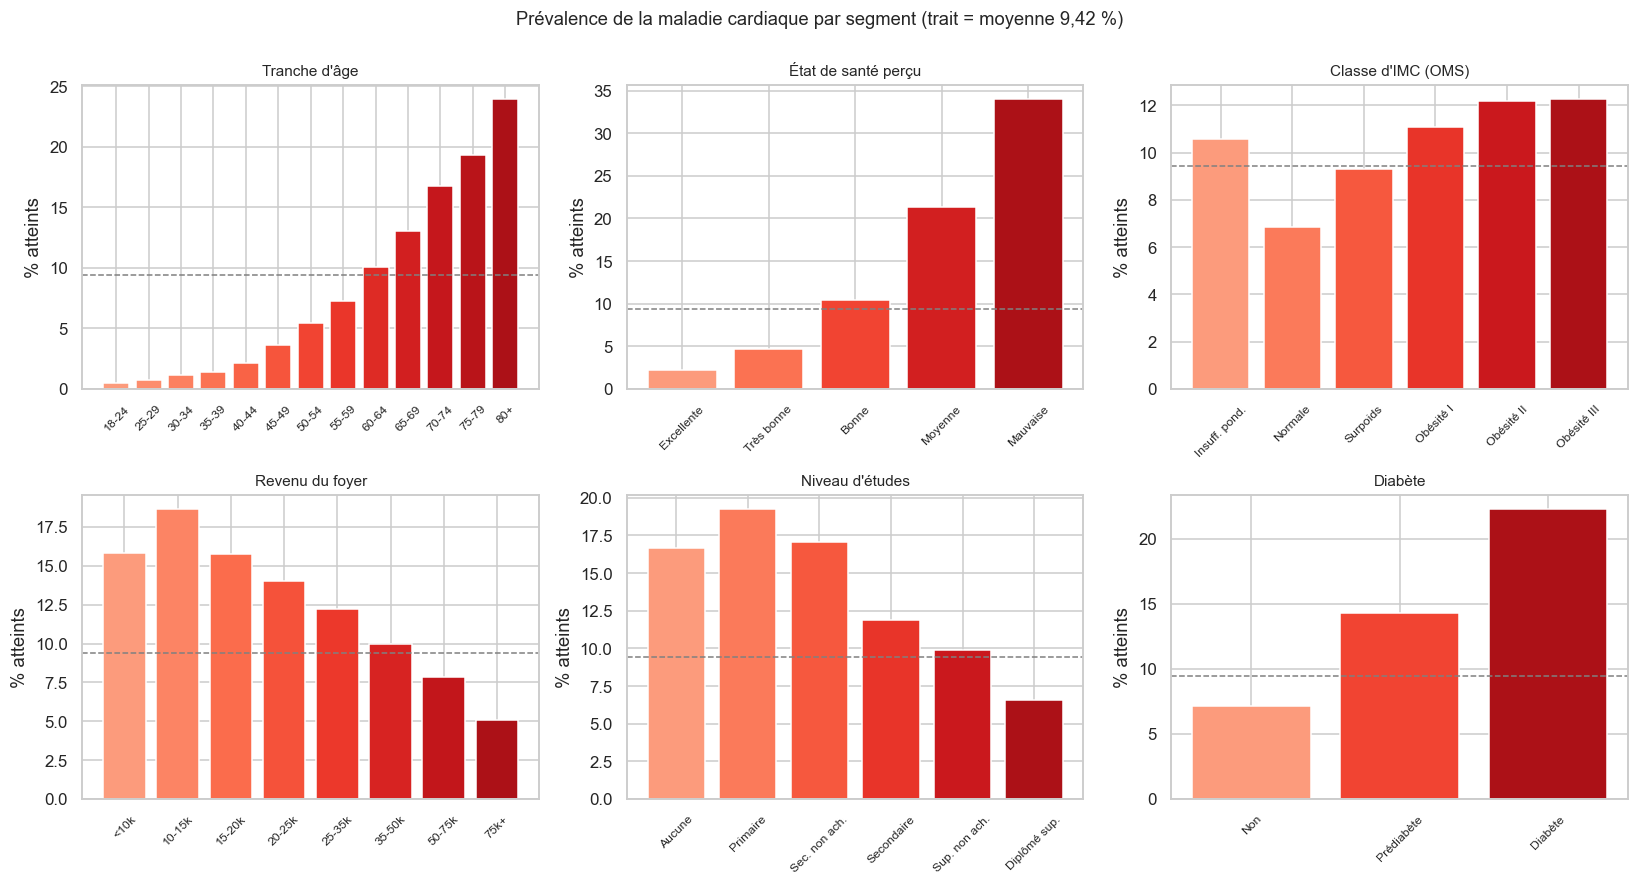

In [13]:
segments = ["age_group", "gen_hlth", "bmi_class", "income", "education", "diabetes"]
titres_seg = {
    "age_group": "Tranche d'âge",
    "gen_hlth": "État de santé perçu",
    "bmi_class": "Classe d'IMC (OMS)",
    "income": "Revenu du foyer",
    "education": "Niveau d'études",
    "diabetes": "Diabète",
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, colonne in zip(axes.ravel(), segments):
    donnees = prevalence_par(colonne)
    couleurs = plt.cm.Reds(np.linspace(0.35, 0.85, len(donnees)))
    ax.bar(donnees.index.astype(str), donnees.prevalence, color=couleurs)
    ax.axhline(9.42, ls="--", c="grey", lw=1)
    ax.set_title(titres_seg[colonne], fontsize=10)
    ax.set_ylabel("% atteints")
    ax.tick_params(axis="x", rotation=45, labelsize=8)

plt.suptitle(
    "Prévalence de la maladie cardiaque par segment (trait = moyenne 9,42 %)",
    y=1.00, fontsize=12,
)
plt.tight_layout()
enregistrer("04_prevalence_segments")
plt.show()

In [14]:
prevalence_par("age_group").round(2)

,effectif,prevalence
age_group,,
18-24,5700,0.51
25-29,7598,0.71
30-34,11123,1.13
35-39,13823,1.40
40-44,16157,2.17
45-49,19819,3.59
50-54,26314,5.42
55-59,30832,7.31
60-64,33244,10.10


**L'âge est le facteur le plus discriminant** : la prévalence passe de moins de
1 % chez les 18-24 ans à plus de 20 % chez les 80 ans et plus. La progression est
strictement monotone.

**L'état de santé perçu est presque aussi puissant** — les personnes se déclarant
en mauvaise santé sont environ dix fois plus touchées que celles se disant en
excellente santé. C'est une variable subjective, mais elle résume beaucoup
d'information clinique.

**Le gradient social est net** : la prévalence décroît régulièrement à mesure que
le revenu et le niveau d'études augmentent.

### La courbe en J de l'IMC

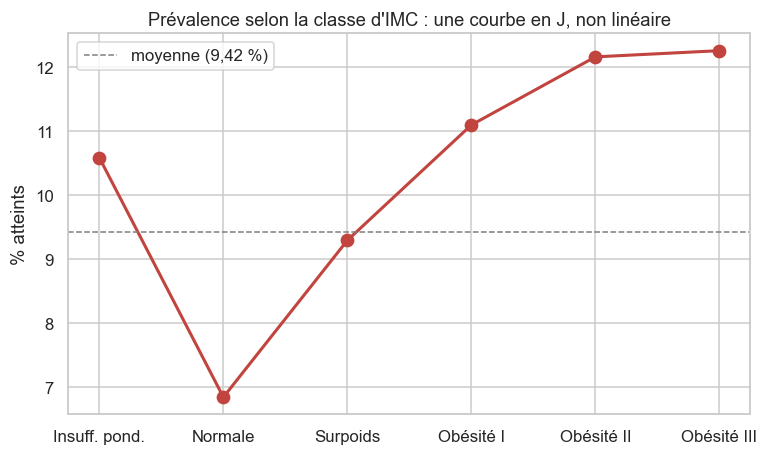

,effectif,prevalence
bmi_class,,
Insuff. pond.,3127,10.59
Normale,68953,6.84
Surpoids,93749,9.30
Obésité I,53451,11.10
Obésité II,20663,12.16
Obésité III,13737,12.26


In [15]:
imc = prevalence_par("bmi_class")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(imc.index.astype(str), imc.prevalence, "o-", color=ROUGE, lw=2, ms=8)
ax.axhline(9.42, ls="--", c="grey", lw=1, label="moyenne (9,42 %)")
ax.set_ylabel("% atteints")
ax.set_title("Prévalence selon la classe d'IMC : une courbe en J, non linéaire")
ax.legend()
enregistrer("05_imc_courbe_j")
plt.show()

imc.round(2)

**Résultat important.** La relation entre IMC et maladie cardiaque **n'est pas
monotone** : les personnes en insuffisance pondérale (10,59 %) sont *plus*
touchées que celles de corpulence normale (6,84 %), à un niveau proche de
l'obésité modérée.

Ce phénomène est bien documenté en épidémiologie — il relève largement de la
**causalité inverse** : la maladie chronique fait maigrir, plutôt que la maigreur
ne cause la maladie. La cohabitation dans le temps des variables (§ limite
méthodologique) empêche de trancher ici.

**Conséquence pratique** : un modèle linéaire appliqué à l'IMC brut manquerait
complètement cette structure. Cela justifie de conserver la **classe d'IMC**
catégorielle en plus de la valeur continue, et privilégie les modèles à base
d'arbres, capables de capturer ce type de non-linéarité.

## 6. Cumul des facteurs de risque

`risk_factor_count` compte les facteurs de risque cardiovasculaire reconnus
présents chez un répondant : hypertension, cholestérol élevé, tabagisme, AVC,
difficulté à marcher, diabète, obésité.

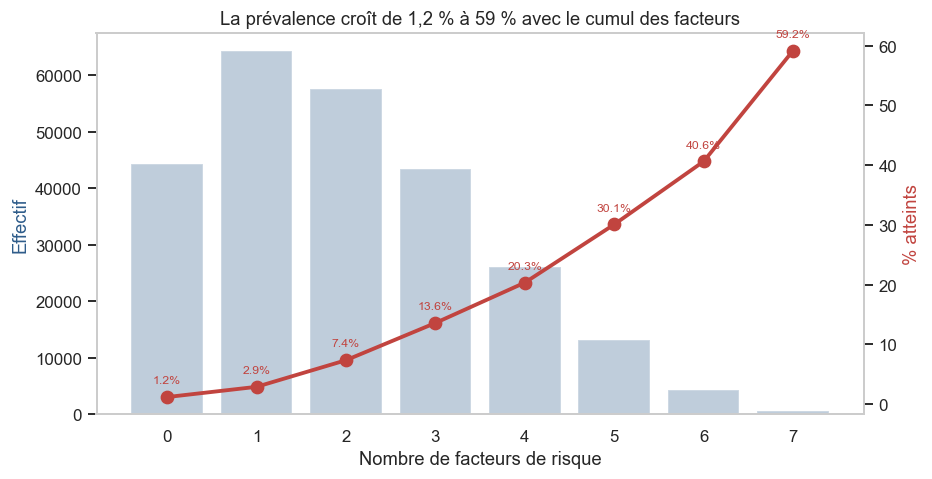

,effectif,prevalence
risk_factor_count,,
0,44325,1.19
1,64232,2.91
2,57632,7.36
3,43430,13.59
4,25990,20.34
5,13117,30.08
6,4371,40.63
7,583,59.18


In [16]:
cumul = df.groupby("risk_factor_count").agg(
    effectif=("heart_disease", "size"),
    prevalence=("heart_disease", "mean"),
)
cumul["prevalence"] *= 100

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(cumul.index, cumul.effectif, color=BLEU, alpha=0.30, label="effectif")
ax1.set_xlabel("Nombre de facteurs de risque")
ax1.set_ylabel("Effectif", color=BLEU)
ax1.grid(False)

ax2 = ax1.twinx()
ax2.plot(cumul.index, cumul.prevalence, "o-", color=ROUGE, lw=2.5, ms=8,
         label="prévalence")
ax2.set_ylabel("% atteints", color=ROUGE)
ax2.grid(False)
for x, y in zip(cumul.index, cumul.prevalence):
    ax2.annotate(f"{y:.1f}%", (x, y), textcoords="offset points",
                 xytext=(0, 9), ha="center", fontsize=8, color=ROUGE)

plt.title("La prévalence croît de 1,2 % à 59 % avec le cumul des facteurs")
enregistrer("06_cumul_facteurs_risque")
plt.show()

cumul.round(2)

Le gradient est **strictement monotone et très étendu** : de **1,19 %** chez les
répondants sans aucun facteur de risque à **59,18 %** chez ceux qui en cumulent
sept — un rapport de 1 à 50.

Cette variable dérivée, construite à partir de sept colonnes, résume à elle seule
une part importante du signal. Elle sera précieuse pour la segmentation et pour
l'application web, où elle offre une lecture immédiate du risque.

## 7. Structure des corrélations

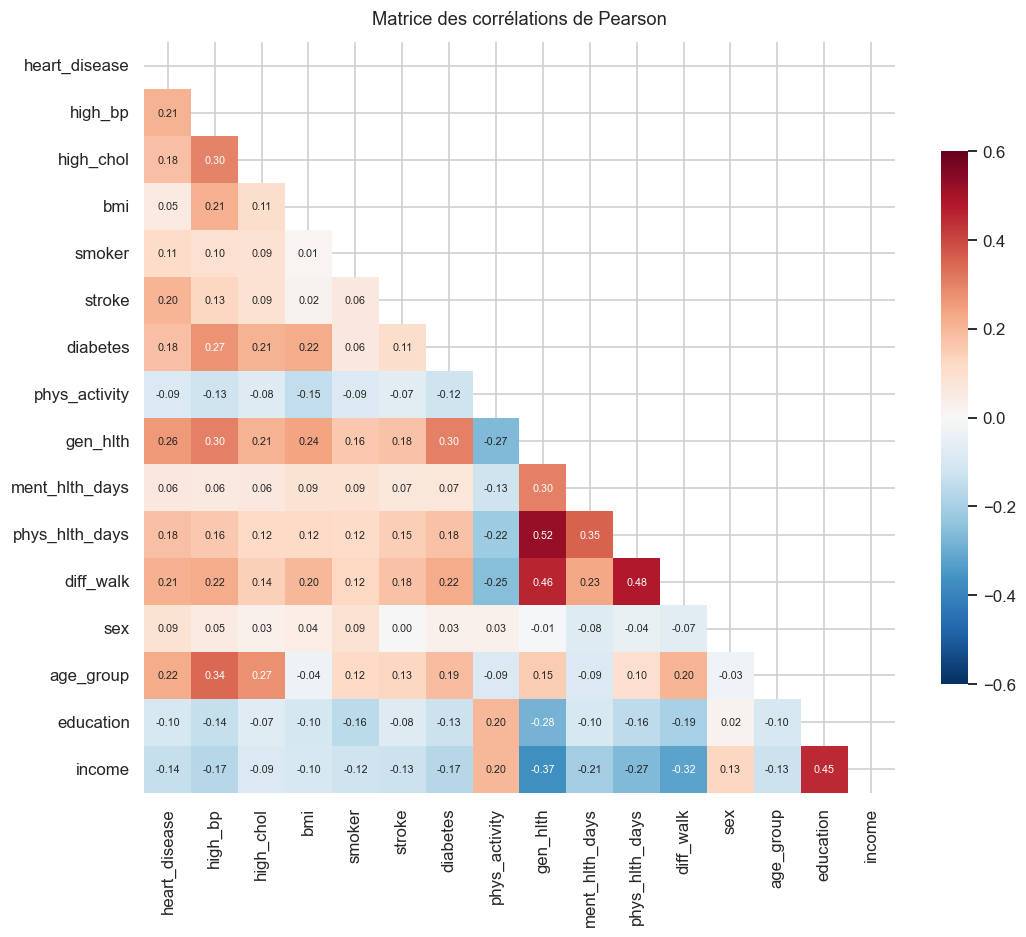

In [17]:
colonnes_corr = [
    "heart_disease", "high_bp", "high_chol", "bmi", "smoker", "stroke",
    "diabetes", "phys_activity", "gen_hlth", "ment_hlth_days",
    "phys_hlth_days", "diff_walk", "sex", "age_group", "education", "income",
]

correlations = df[colonnes_corr].corr()

fig, ax = plt.subplots(figsize=(11, 9))
masque = np.triu(np.ones_like(correlations, dtype=bool))
sns.heatmap(correlations, mask=masque, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-0.6, vmax=0.6, square=True,
            cbar_kws={"shrink": 0.7}, annot_kws={"size": 7}, ax=ax)
ax.set_title("Matrice des corrélations de Pearson", pad=12)
enregistrer("07_correlations")
plt.show()

In [18]:
liens = (
    correlations["heart_disease"]
    .drop("heart_disease")
    .sort_values(key=abs, ascending=False)
    .to_frame("corrélation avec la cible")
)
liens.round(3)

,corrélation avec la cible
gen_hlth,0.258
age_group,0.222
diff_walk,0.213
high_bp,0.209
stroke,0.203
phys_hlth_days,0.182
high_chol,0.181
diabetes,0.180
income,-0.141
smoker,0.114


Aucune corrélation linéaire n'est très forte — la plus élevée avoisine 0,3. C'est
attendu : la plupart des variables sont binaires, et le coefficient de Pearson
mesure mal les relations non linéaires comme la courbe en J de l'IMC.

**Conséquence** : il ne faut pas conclure que ces variables sont peu informatives.
Le cumul des facteurs (§6) montre au contraire un signal très net. Les modèles
non linéaires devraient nettement surpasser une régression logistique simple.

**Aucune paire de variables explicatives n'est fortement corrélée entre elles**
(pas de multicolinéarité problématique) : on peut toutes les conserver.

## 8. Comparaison des profils : atteints contre non atteints

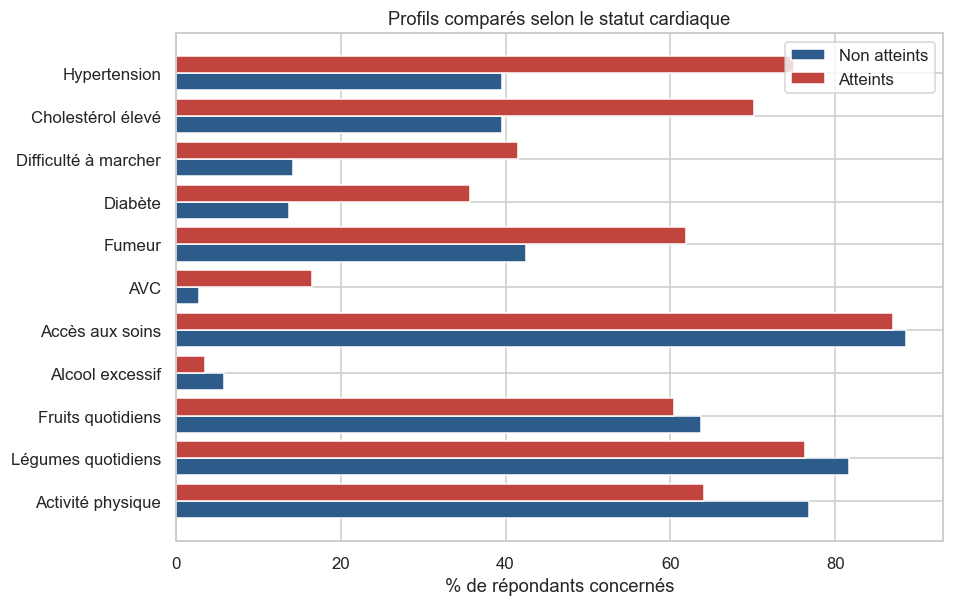

,Non atteints (%),Atteints (%),Écart
Activité physique,76.9,64.0,-12.8
Légumes quotidiens,81.6,76.4,-5.2
Fruits quotidiens,63.7,60.5,-3.3
Alcool excessif,5.8,3.5,-2.3
Accès aux soins,88.6,87.1,-1.6
AVC,2.8,16.5,13.7
Fumeur,42.5,61.9,19.5
Diabète,13.7,35.8,22.1
Difficulté à marcher,14.3,41.5,27.2
Cholestérol élevé,39.5,70.1,30.6


In [19]:
indicateurs = [
    "high_bp", "high_chol", "smoker", "stroke", "diabetes", "phys_activity",
    "fruits", "veggies", "hvy_alcohol", "diff_walk", "has_care_access",
]
noms = [
    "Hypertension", "Cholestérol élevé", "Fumeur", "AVC", "Diabète",
    "Activité physique", "Fruits quotidiens", "Légumes quotidiens",
    "Alcool excessif", "Difficulté à marcher", "Accès aux soins",
]

profils = pd.DataFrame({
    "Non atteints (%)": [df.loc[df.heart_disease == 0, c].gt(0).mean() * 100 for c in indicateurs],
    "Atteints (%)": [df.loc[df.heart_disease == 1, c].gt(0).mean() * 100 for c in indicateurs],
}, index=noms)
profils["Écart"] = profils["Atteints (%)"] - profils["Non atteints (%)"]
profils = profils.sort_values("Écart")

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(profils))
ax.barh(y - 0.2, profils["Non atteints (%)"], height=0.4, color=BLEU, label="Non atteints")
ax.barh(y + 0.2, profils["Atteints (%)"], height=0.4, color=ROUGE, label="Atteints")
ax.set_yticks(y)
ax.set_yticklabels(profils.index)
ax.set_xlabel("% de répondants concernés")
ax.set_title("Profils comparés selon le statut cardiaque")
ax.legend()
enregistrer("08_profils_compares")
plt.show()

profils.round(1)

Les écarts les plus marqués concernent la **difficulté à marcher**, l'**AVC**,
l'**hypertension** et le **cholestérol élevé**. À l'inverse, l'**activité
physique** est plus fréquente chez les non atteints — le seul indicateur nettement
protecteur.

L'**alcool excessif** apparaît paradoxalement plus fréquent chez les non atteints.
Il faut y voir un effet de structure plutôt qu'un effet protecteur : les gros
consommateurs déclarés sont en moyenne plus jeunes, et l'âge domine largement le
risque.

## 9. Synthèse

### Qualité des données

| Point | Constat | Décision |
|---|---|---|
| Valeurs manquantes | Aucune | Pas d'imputation nécessaire |
| Doublons exacts | 23 899 (9,42 %) | **Conservés** — collisions légitimes, démontré par 4 tests |
| IMC extrêmes | 832 lignes hors [14, 60] | Signalés par `flag_bmi_extreme`, non supprimés |
| Incohérences santé | 7 213 lignes | Signalées, légitimes (maladie chronique stabilisée) |

### Facteurs associés, par ordre d'importance

1. **Âge** — de moins de 1 % à plus de 20 % de prévalence
2. **État de santé perçu** — rapport d'environ 1 à 10
3. **Cumul de facteurs de risque** — de 1,2 % à 59 %
4. **Antécédent d'AVC, difficulté à marcher, hypertension, cholestérol**
5. **Gradient socio-économique** — revenu et niveau d'études

### Ce que l'analyse impose à la modélisation

- **Ne pas utiliser l'exactitude** : à 9,42 % de positifs, prédire « aucun malade »
  donnerait 90,58 %. Critères retenus : ROC-AUC, PR-AUC, rappel, F1.
- **Traiter le déséquilibre** : pondération des classes, comparée à SMOTE.
- **Privilégier les modèles non linéaires** : la courbe en J de l'IMC et la
  faiblesse des corrélations de Pearson montrent que le signal n'est pas linéaire.
- **Quantifier l'erreur irréductible** : des profils identiques portent des cibles
  opposées, ce qui plafonne la performance atteignable.
- **Rester prudent sur l'interprétation** : associations transversales, pas de
  causalité — à rappeler dans tous les livrables.